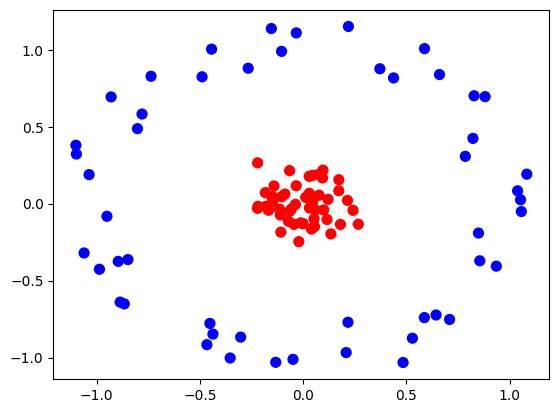

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.45

In [4]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                 stop = X_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1, 
                                 stop = X_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16264\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


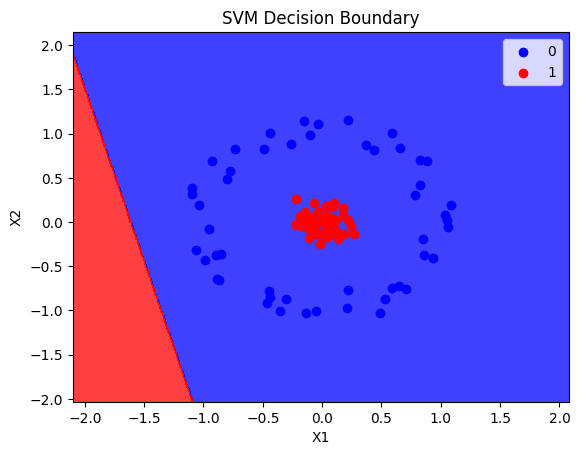

In [5]:
plot_decision_boundary(X, y, classifier)

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

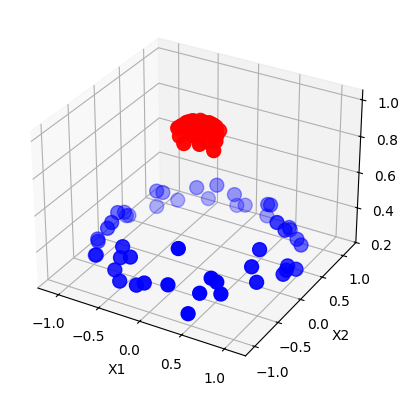

In [6]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax
plot_3d_plot(X,y)

In [7]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)


In [8]:
accuracy_score(y_test, y_pred)

1.0

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16264\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


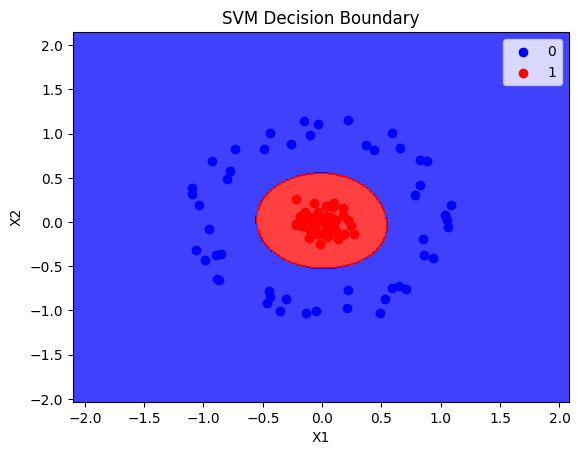

In [9]:
plot_decision_boundary(X, y, rbf_classifier)

In [10]:

poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [11]:
accuracy_score(y_test, y_pred)

1.0

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16264\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


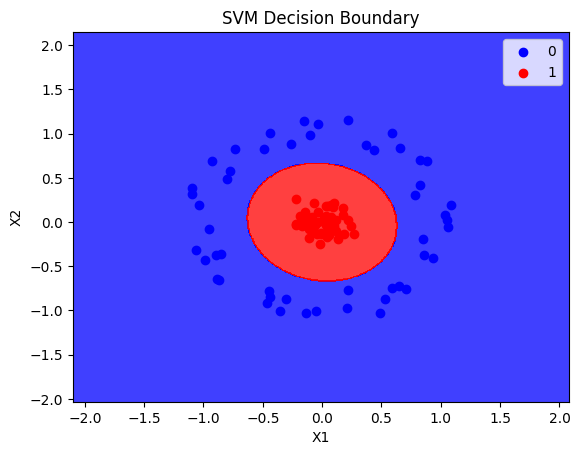

In [12]:
plot_decision_boundary(X, y, poly_classifier)

In [13]:
X

array([[ 8.81322203e-01,  6.95433582e-01],
       [-1.41023097e-01,  1.15029946e-01],
       [ 1.20662552e-01,  2.81476306e-02],
       [ 2.97217414e-02,  1.77698846e-01],
       [ 1.29309221e-02,  4.08957663e-02],
       [-2.20852883e-01, -3.03099576e-02],
       [ 5.29334949e-02, -9.85144200e-02],
       [-2.06060197e-02, -2.46644802e-01],
       [-8.65943421e-01, -6.51124621e-01],
       [-7.36308774e-01,  8.27999025e-01],
       [-4.43311632e-01,  1.00407167e+00],
       [-1.81237139e-01, -1.74968603e-02],
       [ 4.08469171e-02, -1.64966457e-01],
       [-4.65838440e-01, -9.16300545e-01],
       [ 9.61517535e-02,  2.17753517e-01],
       [ 1.08324433e+00,  1.91627793e-01],
       [-4.51237314e-01, -7.78178627e-01],
       [-6.54614177e-02,  2.14645508e-01],
       [ 9.35515324e-01, -4.05907765e-01],
       [-2.20258339e-01,  2.65286953e-01],
       [-1.03704776e-01,  4.52976399e-02],
       [ 2.67361416e-01, -1.33660185e-01],
       [-3.30435835e-02,  1.10960203e+00],
       [ 8.

In [14]:
np.exp(-(X**2)).sum(1)

array([1.07645059, 1.96716421, 1.98475405, 1.96803347, 1.99816174,
       1.95147617, 1.98754382, 1.94055523, 1.12688155, 1.08529307,
       1.18647041, 1.96738061, 1.97148595, 1.23680593, 1.94448746,
       1.27325267, 1.36154392, 1.95069651, 1.26487955, 1.88468647,
       1.98725317, 1.91330651, 1.29084589, 1.11541071, 1.38419664,
       1.31399733, 1.99858536, 1.03937801, 1.28656654, 1.32816325,
       1.95322604, 1.31411379, 1.50619152, 1.98202818, 1.96202078,
       1.31774509, 1.33460773, 1.32926239, 1.98849292, 1.35221266,
       1.39887463, 1.25653597, 1.97711265, 1.98833367, 1.96450677,
       1.29400248, 1.22717493, 1.97542477, 1.33840595, 1.98334585,
       1.94655358, 1.21200938, 1.9783064 , 1.34364681, 1.16383287,
       1.99102399, 1.99352775, 1.36459071, 1.07009174, 1.9704859 ,
       1.98257289, 1.95441378, 1.39261842, 1.97508984, 1.98019983,
       1.4493076 , 1.36337579, 1.17247464, 1.99457385, 1.98444918,
       1.95893303, 1.96348966, 1.3571465 , 1.97621745, 1.13588

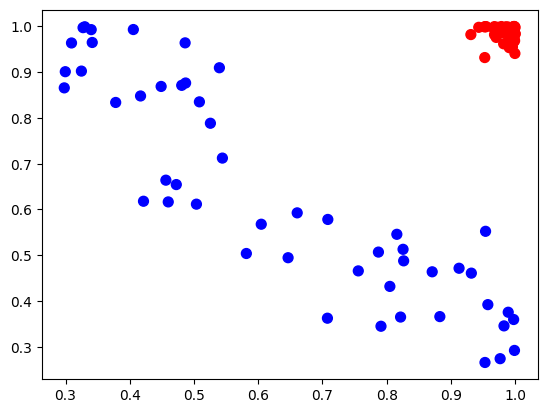

In [15]:
X_new=np.exp(-(X**2))
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')